In [3]:
import polars as pl
import numpy as np
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import os
from collections import defaultdict
import datetime as dt
from pathlib import Path
import sys
sys.path.insert(1, os.path.abspath(".."))
os.chdir(os.path.abspath('..')) # Change the workdir to the parent folder

In [4]:
from src.configs.dataconfig import input_output_config_2
from src.utils.utils import load_df

In [5]:
df_all = load_df(input_output_config_2.output_path, "df_all.parquet")
df_sirs_orig = load_df(input_output_config_2.output_path, "df_sirs_filled.parquet")
df_sirs_postagg = load_df(input_output_config_2.output_path, "df_sirs_postagg.parquet")
df_infect = load_df(input_output_config_2.output_path, "df_infect_long.parquet")

In [13]:
df_all.filter(pl.col('Event_Grouper') == 'Vent On/Off')['Value'].unique()

Value
str
"""Initial"""
"""$ On Going Hospital Vent"""
null
"""Standby"""
"""$ Home Vent Used"""
"""On Going Hospital Vent"""


In [7]:
df_infect.sort(by=['EncounterEpicCsn', 'infect_dt'])

EncounterEpicCsn,criterion,infect_dt,suspicion_infection_type
i64,str,datetime[μs],str
699476058,"""lactate_dt""",2024-05-02 10:30:00,"""LACTATE+CULTURE"""
699476058,"""culture_dt""",2024-05-02 16:29:00,"""LACTATE+CULTURE"""
699476058,"""culture_dt""",2024-05-08 08:20:00,"""IV+Culture"""
699476058,"""iv_dt""",2024-05-09 00:34:00,"""IV+Culture"""
709516764,"""iv_dt""",2025-01-29 21:10:00,"""IV+Culture"""
…,…,…,…
747311714,"""lactate_dt""",2026-02-25 15:14:00,"""LACTATE+CULTURE"""
747311714,"""culture_dt""",2026-02-25 21:01:00,"""IV+Culture"""
747311714,"""culture_dt""",2026-02-25 21:01:00,"""LACTATE+CULTURE"""


In [5]:
df_sirs_groups = df_sirs_postagg.sort(by=['EncounterEpicCsn', 'Event_DateTime']).with_columns(
    pl.when(pl.col("sirs_score")<2).then(pl.lit("<2")).otherwise(pl.lit(">=2")).alias("SIRS_groups")
).with_columns(
    pl.col("SIRS_groups").shift(1).over("EncounterEpicCsn").alias("prev_SIRS_groups")
).with_columns(
    (pl.col("prev_SIRS_groups")!=pl.col("SIRS_groups")).cast(pl.Int32).alias("SIRS_changed")
).with_columns(pl.col("SIRS_changed").fill_null(0)).with_columns(
    pl.col("SIRS_changed").cum_sum().over("EncounterEpicCsn").alias("episodes")
).group_by("EncounterEpicCsn", "episodes").agg(
    pl.col("Event_DateTime").min().alias("episode_start_time"),
    pl.col("Event_DateTime").max().alias("episode_end_time"),
    pl.col("sirs_score").min().alias("min_sirs_score"),
    pl.col("sirs_score").max().alias("max_sirs_score"),
	pl.col("SIRS_groups").first()
).sort(by=['EncounterEpicCsn', 'episode_start_time'])

In [6]:
df_sirs_groups

EncounterEpicCsn,episodes,episode_start_time,episode_end_time,min_sirs_score,max_sirs_score,SIRS_groups
i64,i32,datetime[μs],datetime[μs],i32,i32,str
699476058,0,2024-03-06 03:09:37.020,2024-04-30 21:57:00,0,1,"""<2"""
699476058,1,2024-04-30 21:58:00,2024-04-30 23:17:00,2,3,""">=2"""
699476058,2,2024-04-30 23:19:00,2024-05-01 00:00:00,0,1,"""<2"""
699476058,3,2024-05-01 00:01:00,2024-05-01 00:01:00,2,2,""">=2"""
699476058,4,2024-05-01 00:15:00,2024-05-02 03:20:00,0,1,"""<2"""
…,…,…,…,…,…,…
747311714,8,2026-02-26 21:00:00,2026-02-27 01:10:00,0,1,"""<2"""
747311714,9,2026-02-27 01:20:00,2026-02-27 01:20:00,2,2,""">=2"""
747311714,10,2026-02-27 01:30:00,2026-02-27 03:58:00,0,1,"""<2"""


In [7]:
df_sirs_groups.with_columns(
    episode_duration_hrs = (pl.col("episode_end_time") - pl.col("episode_start_time")).dt.total_hours(fractional=True)
).filter(pl.col("episode_duration_hrs")==0)

EncounterEpicCsn,episodes,episode_start_time,episode_end_time,min_sirs_score,max_sirs_score,SIRS_groups,episode_duration_hrs
i64,i32,datetime[μs],datetime[μs],i32,i32,str,f64
699476058,3,2024-05-01 00:01:00,2024-05-01 00:01:00,2,2,""">=2""",0.0
699476058,10,2024-05-11 05:40:00,2024-05-11 05:40:00,1,1,"""<2""",0.0
699476058,16,2024-05-14 16:00:00,2024-05-14 16:00:00,1,1,"""<2""",0.0
699476058,19,2024-05-16 02:58:00,2024-05-16 02:58:00,2,2,""">=2""",0.0
699476058,25,2024-05-16 11:02:00,2024-05-16 11:02:00,2,2,""">=2""",0.0
…,…,…,…,…,…,…,…
747232821,21,2026-02-27 23:00:00,2026-02-27 23:00:00,1,1,"""<2""",0.0
747311714,5,2026-02-26 20:30:00,2026-02-26 20:30:00,2,2,""">=2""",0.0
747311714,7,2026-02-26 20:50:00,2026-02-26 20:50:00,2,2,""">=2""",0.0


In [8]:
df_infect

EncounterEpicCsn,criterion,infect_dt,suspicion_infection_type
i64,str,datetime[μs],str
735532956,"""iv_dt""",2025-09-18 03:14:32,"""IV+Culture"""
738737076,"""iv_dt""",2025-11-06 13:00:49,"""IV+Culture"""
730753521,"""iv_dt""",2025-07-07 22:20:00,"""IV+Culture"""
727200338,"""iv_dt""",2025-05-11 20:27:00,"""IV+Culture"""
726528293,"""iv_dt""",2025-05-03 05:14:12,"""IV+Culture"""
…,…,…,…
745881507,"""first_ev_time_flowsheet""",2026-02-05 14:56:00,"""FLOWSHEET_SUSPECTED_INFECTION"""
731463364,"""first_ev_time_flowsheet""",2025-07-16 12:00:00,"""FLOWSHEET_SUSPECTED_INFECTION"""
746515486,"""first_ev_time_flowsheet""",2026-02-14 22:18:00,"""FLOWSHEET_SUSPECTED_INFECTION"""


In [9]:
df_joined = df_sirs_groups.join(
    df_infect, on="EncounterEpicCsn", how='left'
).filter(
    (pl.col("episode_start_time")<= (pl.col("infect_dt")+pl.duration(hours=72)) )&
    (pl.col("episode_start_time")>= (pl.col("infect_dt")-pl.duration(hours=72)) )
).with_columns(
    episode_duration_hrs = (pl.col("episode_end_time")-pl.col("episode_start_time")).dt.total_hours(fractional=True)
).sort(by=['EncounterEpicCsn', 'episode_start_time', 'infect_dt'])

In [94]:
df_joined.write_csv("df_sirs_infect_episodes_condition_startdt_only.csv")

In [19]:
df_infect['infect_dt'].n_unique()

11743

In [104]:
df_joined.filter(pl.col("episode_duration_hrs")==0)

EncounterEpicCsn,episodes,episode_start_time,episode_end_time,min_sirs_score,max_sirs_score,SIRS_groups,criterion,infect_dt,suspicion_infection_type,episode_duration_hrs
i64,i32,datetime[μs],datetime[μs],i32,i32,str,str,datetime[μs],str,f64
699476058,3,2024-05-01 00:01:00,2024-05-01 00:01:00,2,2,""">=2""","""lactate_dt""",2024-05-02 10:30:00,"""LACTATE+CULTURE""",0.0
699476058,3,2024-05-01 00:01:00,2024-05-01 00:01:00,2,2,""">=2""","""culture_dt""",2024-05-02 16:29:00,"""LACTATE+CULTURE""",0.0
699476058,10,2024-05-11 05:40:00,2024-05-11 05:40:00,1,1,"""<2""","""culture_dt""",2024-05-08 08:20:00,"""IV+Culture""",0.0
699476058,10,2024-05-11 05:40:00,2024-05-11 05:40:00,1,1,"""<2""","""iv_dt""",2024-05-09 00:34:00,"""IV+Culture""",0.0
709516764,10,2025-01-31 14:43:00,2025-01-31 14:43:00,2,2,""">=2""","""iv_dt""",2025-01-29 21:10:00,"""IV+Culture""",0.0
…,…,…,…,…,…,…,…,…,…,…
747311714,11,2026-02-27 04:00:00,2026-02-27 04:00:00,2,2,""">=2""","""lactate_dt""",2026-02-25 15:14:00,"""LACTATE+CULTURE""",0.0
747311714,11,2026-02-27 04:00:00,2026-02-27 04:00:00,2,2,""">=2""","""culture_dt""",2026-02-25 21:01:00,"""IV+Culture""",0.0
747311714,11,2026-02-27 04:00:00,2026-02-27 04:00:00,2,2,""">=2""","""culture_dt""",2026-02-25 21:01:00,"""LACTATE+CULTURE""",0.0


In [105]:
df_all.filter(
    (pl.col("EncounterEpicCsn")==747311714)&
    (pl.col("Event_DateTime")==dt.datetime(2026, 2, 27, 4))
)

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,EncounterEpicCsn_right,AdmissionDateValue,DischargeDateValue,Arrival_Instant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,LengthOfStayInDays,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_eGFR,Baseline_WBC,First_Suspected_Infection_Time,Suspected_Infection_Criteria_Met,Cancer_Registry_YN,HIV_Registry_YN,Immunocrompromised_Registry_YN,CKD_Dialysis_Registry_YN,Solid_Organ_Transplant_Registry_YN,Pregnancy_Registry_YN
i64,datetime[μs],str,str,str,f64,str,str,i64,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str
747311714,2026-02-27 04:00:00,"""Flowsheet""","""Urine Output""","""GU - URINE OUTPUT (ML)""",25.0,"""25""",null,70491949,747311714,2026-02-25 00:00:00,2026-02-27 00:00:00,2026-02-25 14:51:00,2026-02-25 23:01:00,"""Yes""","""Inpatient""","""Inpatient""","""Acute Care Emergency Surgery""","""2""","""UH 08B MICU""","""UH 02O SICU""","""Emergency""","""Trans from Skilled Nursing Fac…","""ED Admission""","""Ischemic colitis (*)""","""Sepsis, unspecified organism""","""Resection of Sigmoid Colon, Op…",1,"""POA-3""","""POA-3""",null,null,null,1.137333,264.090909,0.35,69.153333,9.767273,"""2026-02-25 15:14:00.0000000""","""Lactate + Two Blood Culture Or…","""0""","""0""","""0""","""0""","""0""","""0"""
747311714,2026-02-27 04:00:00,"""Flowsheet""","""Arterial Blood Pressure Mean""","""UTSW R ARTERIAL BLOOD PRESSURE…",77.0,"""77""",null,70491949,747311714,2026-02-25 00:00:00,2026-02-27 00:00:00,2026-02-25 14:51:00,2026-02-25 23:01:00,"""Yes""","""Inpatient""","""Inpatient""","""Acute Care Emergency Surgery""","""2""","""UH 08B MICU""","""UH 02O SICU""","""Emergency""","""Trans from Skilled Nursing Fac…","""ED Admission""","""Ischemic colitis (*)""","""Sepsis, unspecified organism""","""Resection of Sigmoid Colon, Op…",1,"""POA-3""","""POA-3""",null,null,null,1.137333,264.090909,0.35,69.153333,9.767273,"""2026-02-25 15:14:00.0000000""","""Lactate + Two Blood Culture Or…","""0""","""0""","""0""","""0""","""0""","""0"""
747311714,2026-02-27 04:00:00,"""Flowsheet""","""Pulse""","""PULSE""",99.0,"""99""",null,70491949,747311714,2026-02-25 00:00:00,2026-02-27 00:00:00,2026-02-25 14:51:00,2026-02-25 23:01:00,"""Yes""","""Inpatient""","""Inpatient""","""Acute Care Emergency Surgery""","""2""","""UH 08B MICU""","""UH 02O SICU""","""Emergency""","""Trans from Skilled Nursing Fac…","""ED Admission""","""Ischemic colitis (*)""","""Sepsis, unspecified organism""","""Resection of Sigmoid Colon, Op…",1,"""POA-3""","""POA-3""",null,null,null,1.137333,264.090909,0.35,69.153333,9.767273,"""2026-02-25 15:14:00.0000000""","""Lactate + Two Blood Culture Or…","""0""","""0""","""0""","""0""","""0""","""0"""
747311714,2026-02-27 04:00:00,"""Flowsheet""","""Respirations""","""RESPIRATIONS""",21.0,"""21""",null,70491949,747311714,2026-02-25 00:00:00,2026-02-27 00:00:00,2026-02-25 14:51:00,2026-02-25 23:01:00,"""Yes""","""Inpatient""","""Inpatient""","""Acute Care Emergency Surgery""","""2""","""UH 08B MICU""","""UH 02O SICU""","""Emergency""","""Trans from Skilled Nursing Fac…","""ED Admission""","""Ischemic colitis (*)""","""Sepsis, unspecified organism""","""Resection of Sigmoid Colon, Op…",1,"""POA-3""","""POA-3""",null,null,null,1.137333,264.090909,0.35,69.153333,9.767273,"""2026-02-25 15:14:00.0000000""","""Lactate + Two Blood Culture Or…","""0""","""0""","""0""","""0""","""0""","""0"""
747311714,2026-02-27 04:00:00,"""Flowsheet""","""Blood Pressure""","""BLOOD PRESSURE""",120.0,"""120/102""",null

In [ ]:
df_sirs_postagg.filter(
    (pl.col("EncounterEpicCsn")==747311714)&
    (
        (pl.col("Event_DateTime")==dt.datetime(2026, 2, 27, 4))
	)
)

EncounterEpicCsn,Event_DateTime,last_temp_8h,last_pulse_8h,last_resp_8h,last_sbp_8h,last_map_8h,last_wbc_12h,last_creatinine_12h,last_egfr_12h,last_bilirubin_12h,last_lactate_6h,last_platelets_24h,last_inr_12h,last_aptt_24h,last_gcs_12h,last_vasopressin_24h,last_phenylephrine_24h,last_norepinephrine_24h,last_epinephrine_24h,Temp_Abnormal_Flag,HR_High_Flag,Resp_Rate_High_Flag,WBC_Abnormal_Flag,sirs_score
i64,datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32
747311714,2026-02-27 04:00:00,99.1,99.0,21.0,120.0,108.0,5.04,0.81,90.0,0.6,6.3,130.0,null,null,10.0,0.03,null,0.25,0.07,0,1,1,0,2


In [10]:
print(f'Total # of suspected infection rows: {len(df_infect)}')
print(f'Total # of suspected infection events: {df_infect["infect_dt"].n_unique()}')
print(f'Total # of suspected infection events with SIRS episode starting within +/-72 hours: {df_joined["infect_dt"].n_unique()}')


Total # of suspected infection rows: 16621
Total # of suspected infection events: 11804
Total # of suspected infection events with SIRS episode starting within +/-72 hours: 11717


In [41]:
df_joined

EncounterEpicCsn,episodes,episode_start_time,episode_end_time,min_sirs_score,max_sirs_score,SIRS_groups,criterion,infect_dt,suspicion_infection_type,episode_duration_hrs
i64,i32,datetime[μs],datetime[μs],i32,i32,str,str,datetime[μs],str,f64
699476058,1,2024-04-30 21:58:00,2024-04-30 23:17:00,2,3,""">=2""","""lactate_dt""",2024-05-02 10:30:00,"""LACTATE+CULTURE""",1.316667
699476058,1,2024-04-30 21:58:00,2024-04-30 23:17:00,2,3,""">=2""","""culture_dt""",2024-05-02 16:29:00,"""LACTATE+CULTURE""",1.316667
699476058,2,2024-04-30 23:19:00,2024-05-01 00:00:00,0,1,"""<2""","""lactate_dt""",2024-05-02 10:30:00,"""LACTATE+CULTURE""",0.683333
699476058,2,2024-04-30 23:19:00,2024-05-01 00:00:00,0,1,"""<2""","""culture_dt""",2024-05-02 16:29:00,"""LACTATE+CULTURE""",0.683333
699476058,3,2024-05-01 00:01:00,2024-05-01 00:01:00,2,2,""">=2""","""lactate_dt""",2024-05-02 10:30:00,"""LACTATE+CULTURE""",0.0
…,…,…,…,…,…,…,…,…,…,…
747311714,12,2026-02-27 04:07:00,2026-03-07 02:31:45.340,0,1,"""<2""","""lactate_dt""",2026-02-25 15:14:00,"""LACTATE+CULTURE""",190.412594
747311714,12,2026-02-27 04:07:00,2026-03-07 02:31:45.340,0,1,"""<2""","""culture_dt""",2026-02-25 21:01:00,"""IV+Culture""",190.412594
747311714,12,2026-02-27 04:07:00,2026-03-07 02:31:45.340,0,1,"""<2""","""culture_dt""",2026-02-25 21:01:00,"""LACTATE+CULTURE""",190.412594


In [100]:
df_joined.filter(pl.col("episode_duration_hrs")>0)

EncounterEpicCsn,episodes,episode_start_time,episode_end_time,min_sirs_score,max_sirs_score,SIRS_groups,criterion,infect_dt,suspicion_infection_type,episode_duration_hrs
i64,i32,datetime[μs],datetime[μs],i32,i32,str,str,datetime[μs],str,f64
699476058,1,2024-04-30 21:58:00,2024-04-30 23:17:00,2,3,""">=2""","""lactate_dt""",2024-05-02 10:30:00,"""LACTATE+CULTURE""",1.316667
699476058,1,2024-04-30 21:58:00,2024-04-30 23:17:00,2,3,""">=2""","""culture_dt""",2024-05-02 16:29:00,"""LACTATE+CULTURE""",1.316667
699476058,2,2024-04-30 23:19:00,2024-05-01 00:00:00,0,1,"""<2""","""lactate_dt""",2024-05-02 10:30:00,"""LACTATE+CULTURE""",0.683333
699476058,2,2024-04-30 23:19:00,2024-05-01 00:00:00,0,1,"""<2""","""culture_dt""",2024-05-02 16:29:00,"""LACTATE+CULTURE""",0.683333
699476058,4,2024-05-01 00:15:00,2024-05-02 03:20:00,0,1,"""<2""","""lactate_dt""",2024-05-02 10:30:00,"""LACTATE+CULTURE""",27.083333
…,…,…,…,…,…,…,…,…,…,…
747311714,12,2026-02-27 04:07:00,2026-03-07 02:31:45.340,0,1,"""<2""","""lactate_dt""",2026-02-25 15:14:00,"""LACTATE+CULTURE""",190.412594
747311714,12,2026-02-27 04:07:00,2026-03-07 02:31:45.340,0,1,"""<2""","""culture_dt""",2026-02-25 21:01:00,"""IV+Culture""",190.412594
747311714,12,2026-02-27 04:07:00,2026-03-07 02:31:45.340,0,1,"""<2""","""culture_dt""",2026-02-25 21:01:00,"""LACTATE+CULTURE""",190.412594


In [17]:
df_joined

EncounterEpicCsn,episodes,episode_start_time,episode_end_time,min_sirs_score,max_sirs_score,SIRS_groups,criterion,infect_dt,suspicion_infection_type,episode_duration_hrs
i64,i32,datetime[μs],datetime[μs],i32,i32,str,str,datetime[μs],str,f64
699476058,1,2024-04-30 21:58:00,2024-04-30 23:17:00,2,3,""">=2""","""lactate_dt""",2024-05-02 10:30:00,"""LACTATE+CULTURE""",1.316667
699476058,1,2024-04-30 21:58:00,2024-04-30 23:17:00,2,3,""">=2""","""culture_dt""",2024-05-02 16:29:00,"""LACTATE+CULTURE""",1.316667
699476058,2,2024-04-30 23:19:00,2024-05-01 00:00:00,0,1,"""<2""","""lactate_dt""",2024-05-02 10:30:00,"""LACTATE+CULTURE""",0.683333
699476058,2,2024-04-30 23:19:00,2024-05-01 00:00:00,0,1,"""<2""","""culture_dt""",2024-05-02 16:29:00,"""LACTATE+CULTURE""",0.683333
699476058,3,2024-05-01 00:01:00,2024-05-01 00:01:00,2,2,""">=2""","""lactate_dt""",2024-05-02 10:30:00,"""LACTATE+CULTURE""",0.0
…,…,…,…,…,…,…,…,…,…,…
747311714,12,2026-02-27 04:07:00,2026-03-07 02:31:45.340,0,1,"""<2""","""lactate_dt""",2026-02-25 15:14:00,"""LACTATE+CULTURE""",190.412594
747311714,12,2026-02-27 04:07:00,2026-03-07 02:31:45.340,0,1,"""<2""","""culture_dt""",2026-02-25 21:01:00,"""IV+Culture""",190.412594
747311714,12,2026-02-27 04:07:00,2026-03-07 02:31:45.340,0,1,"""<2""","""culture_dt""",2026-02-25 21:01:00,"""LACTATE+CULTURE""",190.412594


In [9]:
df_agg_episodes = (

		# To exclude
		df_joined.filter(pl.col("episode_duration_hrs") > 0)

        .group_by("EncounterEpicCsn","infect_dt").agg(
		(pl.col("SIRS_groups")==">=2").sum().alias('SIRS>=2_count'),
		(pl.col("SIRS_groups")=="<2").sum().alias('SIRS<2_count'),
		(pl.when(pl.col("SIRS_groups")==">=2").then(pl.col("episode_duration_hrs")).otherwise(pl.lit(0))).sum().alias('SIRS>=2_total_duration'),
		(pl.when(pl.col("SIRS_groups")=="<2").then(pl.col("episode_duration_hrs")).otherwise(pl.lit(0))).sum().alias('SIRS<2_total_duration'),
		(pl.when(pl.col("SIRS_groups")==">=2").then(pl.col("episode_duration_hrs")).otherwise(pl.lit(0))).max().alias('SIRS>=2_max_duration'),
		(pl.when(pl.col("SIRS_groups")=="<2").then(pl.col("episode_duration_hrs")).otherwise(pl.lit(0))).max().alias('SIRS<2_max_duration'),
		(pl.when(pl.col("SIRS_groups")==">=2").then(pl.col("episode_duration_hrs")).otherwise(pl.lit(1e30))).min().alias('SIRS>=2_min_duration'),
		(pl.when(pl.col("SIRS_groups")=="<2").then(pl.col("episode_duration_hrs")).otherwise(pl.lit(1e30))).min().alias('SIRS<2_min_duration'),
	).sort(by=['EncounterEpicCsn', "infect_dt"])
)

In [92]:
df_agg_episodes.write_csv("df_agg_infect_episodes_viz.csv")

In [10]:
df_agg_episodes

EncounterEpicCsn,infect_dt,SIRS>=2_count,SIRS<2_count,SIRS>=2_total_duration,SIRS<2_total_duration,SIRS>=2_max_duration,SIRS<2_max_duration,SIRS>=2_min_duration,SIRS<2_min_duration
i64,datetime[μs],u64,u64,f64,f64,f64,f64,f64,f64
699476058,2024-05-02 10:30:00,2,2,200.483333,27.766667,199.166667,27.083333,1.316667,0.683333
699476058,2024-05-02 16:29:00,2,2,200.483333,27.766667,199.166667,27.083333,1.316667,0.683333
699476058,2024-05-08 08:20:00,3,2,34.983333,0.333333,19.0,0.183333,0.316667,0.15
699476058,2024-05-09 00:34:00,3,2,34.983333,0.333333,19.0,0.183333,0.316667,0.15
709516764,2025-01-29 21:10:00,7,7,71.389557,33.65,20.466667,10.55,0.616667,0.016667
…,…,…,…,…,…,…,…,…,…
747262992,2026-02-25 10:38:22,2,2,41.25,12.505833,34.566667,11.379444,6.683333,1.126389
747311714,2026-02-25 15:14:00,2,7,10.083333,216.295094,10.0,190.412594,0.083333,0.1
747311714,2026-02-25 21:01:00,4,14,20.166667,432.590189,10.0,190.412594,0.083333,0.1


<Axes: xlabel='SIRS>=2_count', ylabel='Count'>

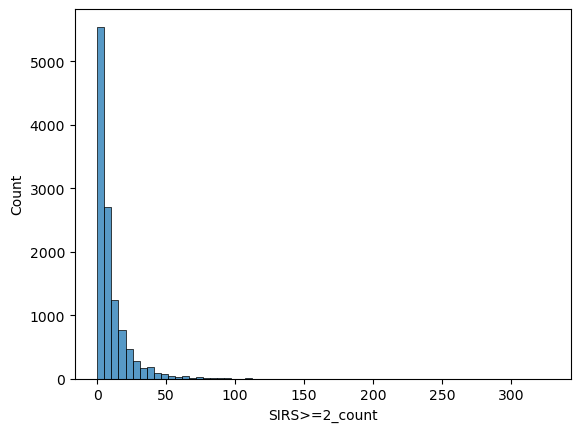

In [58]:
sns.histplot(
    data=df_agg_episodes.to_pandas(),
    x = "SIRS>=2_count",
    bins=64
)

[Text(0, 0, 'SIRS<2_total_duration')]

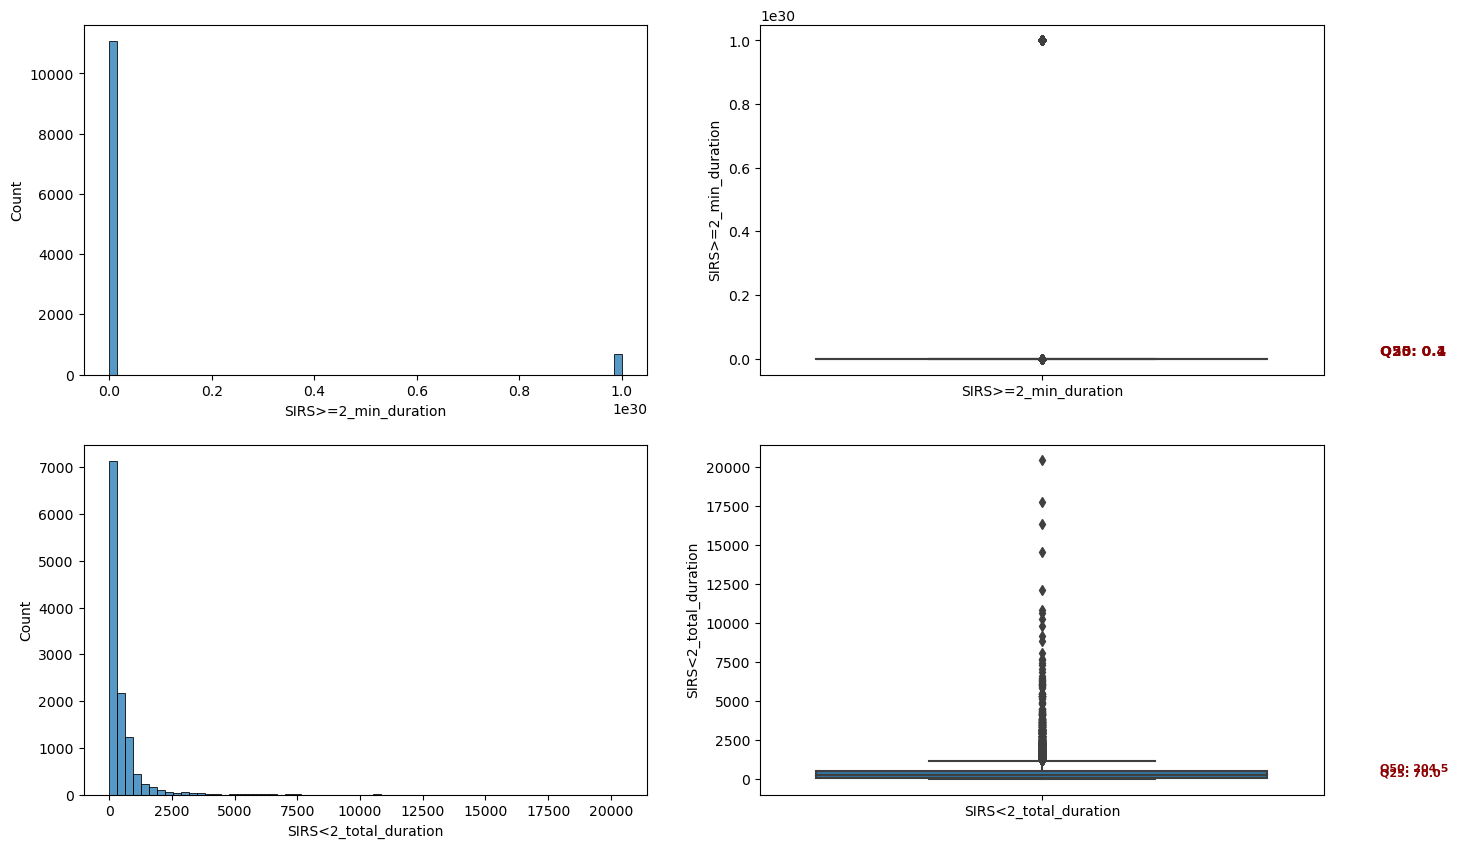

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16,10))
sns.histplot(
    data=df_agg_episodes.to_pandas(),
    x = "SIRS>=2_min_duration",
    bins=64,
    ax=axes[0][0]
)
sns.boxplot(
    data=df_agg_episodes.to_pandas(),
    y = "SIRS>=2_min_duration",
    ax=axes[0][1]
)
sns.histplot(
    data=df_agg_episodes.to_pandas(),
    x = "SIRS<2_total_duration",
    bins=64,
    ax=axes[1][0]
)
sns.boxplot(
    data=df_agg_episodes.to_pandas(),
    y = "SIRS<2_total_duration",
    ax=axes[1][1]
)

q50 = df_agg_episodes['SIRS>=2_min_duration'].median()
q25 = df_agg_episodes['SIRS>=2_min_duration'].quantile(0.25)
axes[0][1].text(
	0.60, q50 + 8.1, f"Q50: {q50:.1f}", fontsize=10, color="darkred", fontweight="bold", va="bottom"
)
axes[0][1].text(
	0.60, q25 - 8.2 , f"Q25: {q25:.1f}", fontsize=10, color="darkred", fontweight="bold", va="bottom"
)
axes[0][1].set_xticklabels(['SIRS>=2_min_duration'])

q50 = df_agg_episodes['SIRS<2_total_duration'].median()
q25 = df_agg_episodes['SIRS<2_total_duration'].quantile(0.25)
axes[1][1].text(
	0.60, q50 + 150.1, f"Q50: {q50:.1f}", fontsize=8, color="darkred", fontweight="bold", va="bottom"
)
axes[1][1].text(
	0.60, q25 - 8.2 , f"Q25: {q25:.1f}", fontsize=8, color="darkred", fontweight="bold", va="bottom"
)
axes[1][1].set_xticklabels(['SIRS<2_total_duration'])

<Axes: ylabel='SIRS<2_total_duration'>

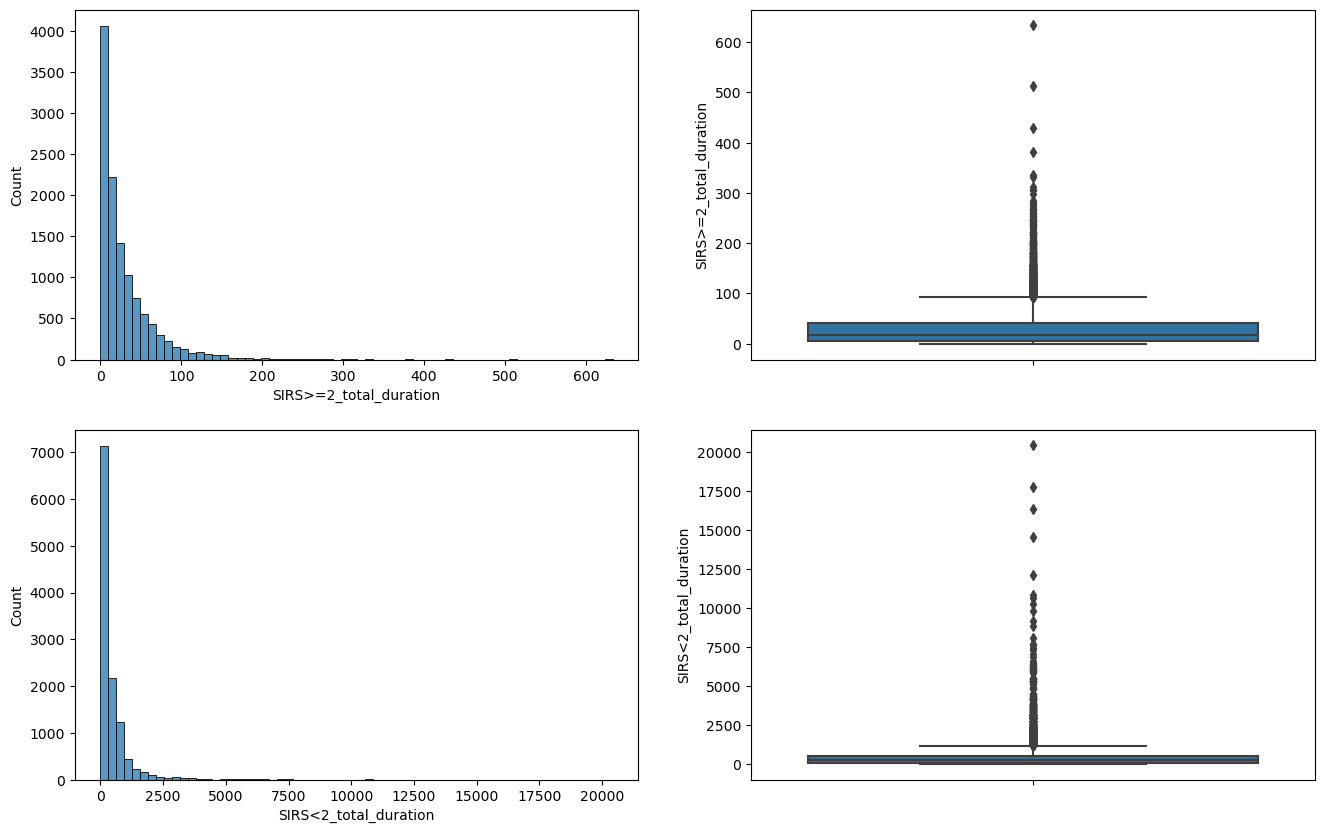

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(16,10))
sns.histplot(
    data=df_agg_episodes.to_pandas(),
    x = "SIRS>=2_total_duration",
    bins=64,
    ax=axes[0][0]
)
sns.boxplot(
    data=df_agg_episodes.to_pandas(),
    y = "SIRS>=2_total_duration",
    ax=axes[0][1]
)
sns.histplot(
    data=df_agg_episodes.to_pandas(),
    x = "SIRS<2_total_duration",
    bins=64,
    ax=axes[1][0]
)
sns.boxplot(
    data=df_agg_episodes.to_pandas(),
    y = "SIRS<2_total_duration",
    ax=axes[1][1]
)

# q50 = df_agg_episodes['SIRS>=2_min_duration'].median()
# q25 = df_agg_episodes['SIRS>=2_min_duration'].quantile(0.25)
# q75 = df_agg_episodes['SIRS>=2_min_duration'].quantile(0.75)
# axes[0][1].text(
# 	0.60, q50 + 18.1, f"Q50: {q50:.1f}", fontsize=10, color="darkred", fontweight="bold", va="bottom"
# )
# axes[0][1].text(
# 	0.60, q25 - 8.2 , f"Q25: {q25:.1f}", fontsize=10, color="darkred", fontweight="bold", va="bottom"
# )
# axes[0][1].text(
# 	0.60, q75 + 48.2 , f"Q75: {q75:.1f}", fontsize=10, color="darkred", fontweight="bold", va="bottom"
# )
# axes[0][1].set_xticklabels(['SIRS>=2_min_duration'])

# q50 = df_agg_episodes['SIRS<2_total_duration'].median()
# q25 = df_agg_episodes['SIRS<2_total_duration'].quantile(0.25)
# axes[1][1].text(
# 	0.60, q50 + 1000.1, f"Q50: {q50:.1f}", fontsize=10, color="darkred", fontweight="bold", va="bottom"
# )
# axes[1][1].text(
# 	0.60, q25 - 8.2 , f"Q25: {q25:.1f}", fontsize=10, color="darkred", fontweight="bold", va="bottom"
# )
# axes[1][1].set_xticklabels(['SIRS<2_total_duration'])

In [18]:
df_agg_ = (
    df_joined.group_by("episode_start_time").agg(
        pl.col("episode_duration_hrs")
	)
)

In [20]:
df_joined

EncounterEpicCsn,episodes,episode_start_time,episode_end_time,min_sirs_score,max_sirs_score,SIRS_groups,criterion,infect_dt,suspicion_infection_type,episode_duration_hrs
i64,i32,datetime[μs],datetime[μs],i32,i32,str,str,datetime[μs],str,f64
699476058,1,2024-04-30 21:58:00,2024-04-30 23:17:00,2,3,""">=2""","""lactate_dt""",2024-05-02 10:30:00,"""LACTATE+CULTURE""",1.316667
699476058,1,2024-04-30 21:58:00,2024-04-30 23:17:00,2,3,""">=2""","""culture_dt""",2024-05-02 16:29:00,"""LACTATE+CULTURE""",1.316667
699476058,2,2024-04-30 23:19:00,2024-05-01 00:00:00,0,1,"""<2""","""lactate_dt""",2024-05-02 10:30:00,"""LACTATE+CULTURE""",0.683333
699476058,2,2024-04-30 23:19:00,2024-05-01 00:00:00,0,1,"""<2""","""culture_dt""",2024-05-02 16:29:00,"""LACTATE+CULTURE""",0.683333
699476058,3,2024-05-01 00:01:00,2024-05-01 00:01:00,2,2,""">=2""","""lactate_dt""",2024-05-02 10:30:00,"""LACTATE+CULTURE""",0.0
…,…,…,…,…,…,…,…,…,…,…
747311714,12,2026-02-27 04:07:00,2026-03-07 02:31:45.340,0,1,"""<2""","""lactate_dt""",2026-02-25 15:14:00,"""LACTATE+CULTURE""",190.412594
747311714,12,2026-02-27 04:07:00,2026-03-07 02:31:45.340,0,1,"""<2""","""culture_dt""",2026-02-25 21:01:00,"""IV+Culture""",190.412594
747311714,12,2026-02-27 04:07:00,2026-03-07 02:31:45.340,0,1,"""<2""","""culture_dt""",2026-02-25 21:01:00,"""LACTATE+CULTURE""",190.412594


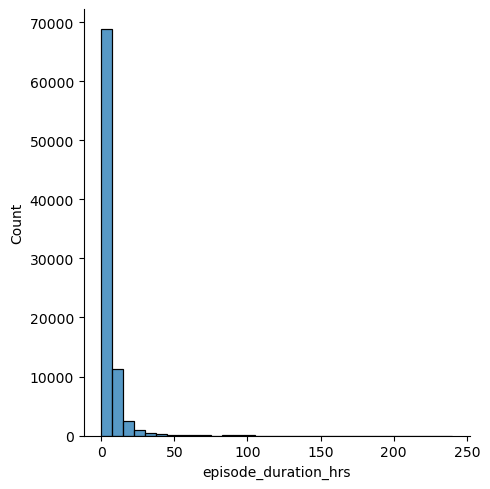

In [26]:
g =sns.displot(data=df_joined.filter(
    (pl.col("SIRS_groups") == '>=2')&(
        pl.col("episode_duration_hrs")>0
	)
).to_pandas(), x='episode_duration_hrs', kind='hist', bins=32)


In [7]:
df_sirs_postagg['sirs_score'].null_count()

0

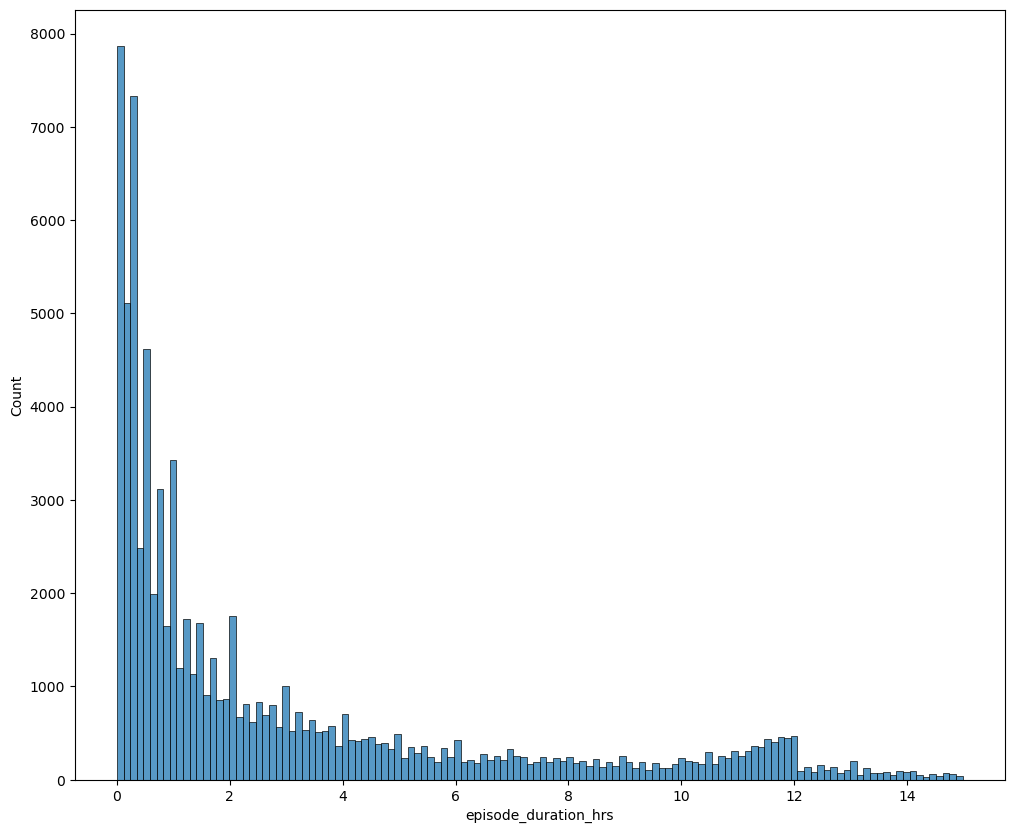

In [8]:
df_sirs_groups = df_sirs_postagg.sort(by=['EncounterEpicCsn', 'Event_DateTime']).with_columns(
    pl.when(pl.col("sirs_score")<2).then(pl.lit("<2")).otherwise(pl.lit(">=2")).alias("SIRS_groups")
).with_columns(
    pl.col("SIRS_groups").shift(1).over("EncounterEpicCsn").alias("prev_SIRS_groups")
).with_columns(
    (pl.col("prev_SIRS_groups")!=pl.col("SIRS_groups")).cast(pl.Int32).alias("SIRS_changed")
).with_columns(pl.col("SIRS_changed").fill_null(0)).with_columns(
    pl.col("SIRS_changed").cum_sum().over("EncounterEpicCsn").alias("episodes")
).group_by("EncounterEpicCsn", "episodes").agg(
    pl.col("Event_DateTime").min().alias("episode_start_time"),
    pl.col("Event_DateTime").max().alias("episode_end_time"),
    pl.col("sirs_score").min().alias("min_sirs_score"),
    pl.col("sirs_score").max().alias("max_sirs_score"),
	pl.col("SIRS_groups").first()
).sort(by=['EncounterEpicCsn', 'episode_start_time'])


df_joined = df_sirs_groups.join(
    df_infect, on="EncounterEpicCsn", how='left'
).filter(
    (pl.col("episode_start_time")<= (pl.col("infect_dt")+pl.duration(hours=72)) )&
    (pl.col("episode_start_time")>= (pl.col("infect_dt")-pl.duration(hours=72)) )
).with_columns(
    episode_duration_hrs = (pl.col("episode_end_time")-pl.col("episode_start_time")).dt.total_hours(fractional=True)
).sort(by=['EncounterEpicCsn', 'episode_start_time', 'infect_dt'])

dd = df_joined.filter(
    (pl.col("SIRS_groups") == '>=2')&(
        (pl.col("episode_duration_hrs")>0)&
        (pl.col("episode_duration_hrs")<15)

	)
)
fig, axes = plt.subplots(1,1,figsize=(12, 10))
g =sns.histplot(data=df_joined.filter(
    (pl.col("SIRS_groups") == '>=2')&(
        (pl.col("episode_duration_hrs")>0)&
        (pl.col("episode_duration_hrs")<15)

	)
).to_pandas(), x='episode_duration_hrs', bins=128)
